# 01 — MDP Formulation
**Week 3 | RL Fundamentals**

A **Markov Decision Process** (MDP) is defined by the 5-tuple:

$$M = (\mathcal{S},\; \mathcal{A},\; \mathcal{R},\; \mathcal{T},\; \gamma)$$

| Symbol | Meaning |
|---|---|
| S | State space |
| A | Action space |
| R(s,a,s') | Reward function |
| T(s,a,s') | Transition function P(s'|s,a) |
| γ ∈ [0,1) | Discount factor |

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. Constructing a Tiny MDP by Hand
A recycling robot (from Sutton & Barto, Example 3.3):  
- **States**: {high battery, low battery}  
- **Actions**: {search, wait, recharge}  
- **Goal**: maximise cans collected

In [7]:
# States
S = ['high', 'low']
s_idx = {s: i for i, s in enumerate(S)}

# Actions (not all available in every state but we'll handle that via masks)
A = ['search', 'wait', 'recharge']
a_idx = {a: i for i, a in enumerate(A)}

# Transition tensor: T[s, a, s'] = P(s'|s,a)
# and Reward matrix:  R[s, a] = expected reward
alpha = 0.9   # P(stay high | high, search)
beta  = 0.4   # P(stay low  | low,  search)
r_search_high = 4.0
r_search_low  = 2.0
r_wait        = 1.0

T = np.zeros((2, 3, 2))   # (states, actions, next_states)
R = np.full((2, 3), -np.inf)  # -inf for illegal actions

# From HIGH
T[0, 0, 0] = alpha;    T[0, 0, 1] = 1 - alpha;  R[0, 0] = r_search_high  # search
T[0, 1, 0] = 1.0;                                R[0, 1] = r_wait         # wait
# recharge not available from high

# From LOW
T[1, 0, 0] = 1-beta;   T[1, 0, 1] = beta;        R[1, 0] = r_search_low   # search
T[1, 1, 1] = 1.0;                                 R[1, 1] = r_wait         # wait
T[1, 2, 0] = 1.0;                                 R[1, 2] = 0.0            # recharge

print("Transition tensor shape:", T.shape, "  (states × actions × next_states)")
print("\nReward matrix R[s,a]:")
for i, s in enumerate(S):
    for j, a in enumerate(A):
        r = R[i, j]
        print(f"  R[{s},{a}] = {r if r != -np.inf else 'N/A'}")

Transition tensor shape: (2, 3, 2)   (states × actions × next_states)

Reward matrix R[s,a]:
  R[high,search] = 4.0
  R[high,wait] = 1.0
  R[high,recharge] = N/A
  R[low,search] = 2.0
  R[low,wait] = 1.0
  R[low,recharge] = 0.0


## 2. Simulate One Episode Under a Random Policy

In [8]:
def valid_actions(s):
    if s == 0:  return [0, 1]        # high: search, wait
    else:       return [0, 1, 2]     # low:  search, wait, recharge

def step(s, a):
    next_s = np.random.choice(2, p=T[s, a])
    r = R[s, a]
    return next_s, r

def simulate_episode(start=0, n_steps=20, gamma=0.95):
    s = start
    trajectory = []
    for t in range(n_steps):
        a = np.random.choice(valid_actions(s))
        next_s, r = step(s, a)
        trajectory.append({'t': t, 'state': S[s], 'action': A[a], 'reward': r, 'next': S[next_s]})
        s = next_s
    return trajectory

traj = simulate_episode()
print(f"{'t':>3}  {'State':<8} {'Action':<10} {'Reward':>7}  {'Next':>8}")
print("-" * 45)
for step_ in traj[:10]:
    print(f"{step_['t']:>3}  {step_['state']:<8} {step_['action']:<10} {step_['reward']:>7.1f}  {step_['next']:>8}")

  t  State    Action      Reward      Next
---------------------------------------------
  0  high     search         4.0      high
  1  high     search         4.0      high
  2  high     wait           1.0      high
  3  high     wait           1.0      high
  4  high     search         4.0      high
  5  high     search         4.0       low
  6  low      recharge       0.0      high
  7  high     wait           1.0      high
  8  high     search         4.0      high
  9  high     wait           1.0      high


# Ans3)

C:\Users\arinu\AppData\Local\Temp\ipykernel_7188\3296359997.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.legend();	plt.tight_layout();	plt.show()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


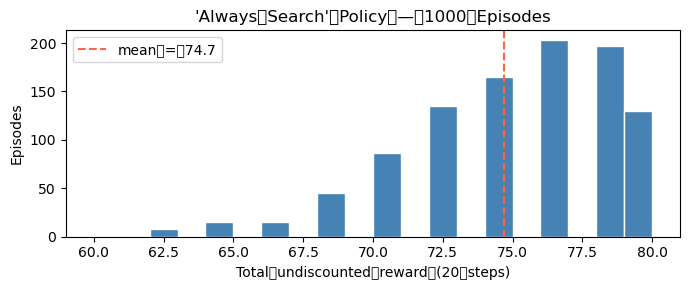

In [12]:
def	simulate_always_search(start=0,	n_steps=20):
				s	=	start
				total	=	0.0
				for	_	in	range(n_steps):
								a	=	0																						#	always	search
								next_s,	r	=	step(s,	a)
								total	+=	r
								s	=	next_s
				return	total
totals	=	[simulate_always_search()	for	_	in	range(1000)]
plt.figure(figsize=(7,	3))
plt.hist(totals,	bins=20,	color='steelblue',	edgecolor='white')
plt.axvline(np.mean(totals),	color='tomato',	linestyle='--',
												label=f'mean	=	{np.mean(totals):.1f}')
plt.xlabel('Total	undiscounted	reward	(20	steps)');	
plt.ylabel('Episodes')
plt.title("'Always	Search'	Policy	—	1000	Episodes")
plt.legend();	plt.tight_layout();	plt.show()

## 3. Real-World MDP Formulations
Practice framing problems as MDPs before coding them.

In [9]:
problems = {
    "Taxi Driver": {
        "States":   "(row, col, passenger_loc, destination) — 500 states",
        "Actions":  "N, S, E, W, Pickup, Dropoff",
        "Reward":   "-1 per step, +20 for delivery, -10 illegal pickup/dropoff",
        "Terminal": "After successful dropoff",
        "gamma":    0.99,
    },
    "CartPole": {
        "States":   "(cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4",
        "Actions":  "Push left (0) or Push right (1)",
        "Reward":   "+1 for every timestep the pole stays upright",
        "Terminal": "Pole falls >15° or cart moves >2.4 from centre",
        "gamma":    1.0,
    },
    "Trading Agent": {
        "States":   "(price_history, holdings, cash, technical_indicators)",
        "Actions":  "Buy / Sell / Hold (continuous or discrete)",
        "Reward":   "Change in portfolio value or Sharpe ratio",
        "Terminal": "End of trading day / time horizon reached",
        "gamma":    0.99,
    },
}

for name, mdp in problems.items():
    print(f"\n=== {name} ===")
    for k, v in mdp.items():
        print(f"  {k:<10}: {v}")


=== Taxi Driver ===
  States    : (row, col, passenger_loc, destination) — 500 states
  Actions   : N, S, E, W, Pickup, Dropoff
  Reward    : -1 per step, +20 for delivery, -10 illegal pickup/dropoff
  Terminal  : After successful dropoff
  gamma     : 0.99

=== CartPole ===
  States    : (cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4
  Actions   : Push left (0) or Push right (1)
  Reward    : +1 for every timestep the pole stays upright
  Terminal  : Pole falls >15° or cart moves >2.4 from centre
  gamma     : 1.0

=== Trading Agent ===
  States    : (price_history, holdings, cash, technical_indicators)
  Actions   : Buy / Sell / Hold (continuous or discrete)
  Reward    : Change in portfolio value or Sharpe ratio
  Terminal  : End of trading day / time horizon reached
  gamma     : 0.99


## ✅ Exercises
1. Formalise a **Frozen Lake 4×4** as an MDP. How many states? How many actions? What are the terminal states?
2. Pick a board game you know (noughts & crosses, connect 4). Define S, A, R, and T for it.
3. **Challenge**: simulate 1000 episodes of the recycling robot under the policy 'always search'. Plot the distribution of total undiscounted reward per episode.

Ans 1) 	S:	16	states	(flat	index	0–15,	one	per
grid	cell)	-	A:	4	actions	(0=Left,	1=Down,	2=Right,	3=Up)	—	same	4
in	every	state	-	R:	+1	on	reaching	Goal	(state	15),	0	everywhere	else	
T:	deterministic	if	is_slippery=False;	if	slippery,	intended	direction
with	p=1/3	and	each	perpendicular	direction	with	p=1/3	-	Terminal
states:	the	4	holes	{5,	7,	11,	12}	and	the	goal	{15}	—	5	terminals
total	-	γ:	typically	0.99	(episodic,	but	discount	encourages	shorter
paths)

In [10]:
mdp_frozenlake	=	{
				"States":			"16	(4x4	grid,	flat	index)",
				"Actions":		"4	(L,	D,	R,	U)",
				"Reward":			"+1	at	Goal	(s=15),	0	otherwise",
				"Terminal":	"Holes	{5,	7,	11,	12}	and	Goal	{15}",
				"gamma":				0.99,
}
for	k,	v	in	mdp_frozenlake.items():
				print(f"		{k:<10}:	{v}")

		States    :	16	(4x4	grid,	flat	index)
		Actions   :	4	(L,	D,	R,	U)
		Reward    :	+1	at	Goal	(s=15),	0	otherwise
		Terminal  :	Holes	{5,	7,	11,	12}	and	Goal	{15}
		gamma     :	0.99


Ans 2) I choose THE LEGENDARY TIC TAC TOE

In [11]:
problems["Tic-Tac-Toe	(vs	fixed	opponent)"]	=	{
				"States":			"Board	configuration:	each	of	9	cells	∈	{empty,	X, O}	→	3^9	=	19,683	raw	(~5,478	legal)",
				"Actions":		"Place	mark	in	any	empty	cell	(≤9	actions,	shrinks	as	board	fills)",
				"Reward":			"+1	win,	-1	loss,	0	draw,	0	for	intermediate	moves",
				"Terminal":	"Three	in	a	row	(either	player)	or	board	full",
				"gamma":				1.0,			#	short	episodic	game	—	no	discounting	needed
}
name	=	"Tic-Tac-Toe	(vs	fixed	opponent)"
print(f"===	{name}	===")
for	k,	v	in	problems[name].items():
				print(f"		{k:<10}:	{v}")


===	Tic-Tac-Toe	(vs	fixed	opponent)	===
		States    :	Board	configuration:	each	of	9	cells	∈	{empty,	X, O}	→	3^9	=	19,683	raw	(~5,478	legal)
		Actions   :	Place	mark	in	any	empty	cell	(≤9	actions,	shrinks	as	board	fills)
		Reward    :	+1	win,	-1	loss,	0	draw,	0	for	intermediate	moves
		Terminal  :	Three	in	a	row	(either	player)	or	board	full
		gamma     :	1.0
